# ST422 Brief 8 — Road Safety Analysis
## Week 9: Data Preparation & Preliminary Analysis

Draft — Week 9

---

This notebook expands the analysis from Week 8 using the full published STATS19 dataset (2014–2024), with provisional 2025 data (January–June only) appended and clearly flagged throughout. The aim is to establish a clean, validated dataset and produce the first set of decision-relevant findings for the client: where serious harm is geographically concentrated, which road users face the greatest risk, and whether the apparent rise in KSI since 2020 reflects real change or a recording artefact.

In [2]:
%reset -f

---
## 1. Data Preparation

The full historical STATS19 files are loaded and filtered to 2014–2024. Provisional 2025 data (January–June) is appended and tagged throughout. Invalid codes (`-1`) are replaced with `NaN` across all categorical fields — longitude is excluded from this since negative values are valid in Great Britain. Date fields are parsed, a month column is extracted for the seasonality check, and readable labels are mapped onto numeric codes for casualty type, urban/rural, road type, junction detail, day of week, and police force. Local authority names are joined from the ONS district lookup. The join key (`collision_index`) is a consistent 13-character string across all three tables with zero orphan records in any year.

In [3]:
%reset -f
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/zahidahmed/Documents/Stats/ST422/Data'

COLLISION_HIST = f'{DATA_DIR}/dft-road-casualty-statistics-collision-1979-latest-published-year.csv'
CASUALTY_HIST  = f'{DATA_DIR}/dft-road-casualty-statistics-casualty-1979-latest-published-year.csv'
VEHICLE_HIST   = f'{DATA_DIR}/dft-road-casualty-statistics-vehicle-1979-latest-published-year.csv'
COLLISION_2025 = f'{DATA_DIR}/dft-road-casualty-statistics-collision-provisional-2025.csv'
CASUALTY_2025  = f'{DATA_DIR}/dft-road-casualty-statistics-casualty-provisional-2025.csv'
VEHICLE_2025   = f'{DATA_DIR}/dft-road-casualty-statistics-vehicle-provisional-2025.csv'
LA_LOOKUP      = f'{DATA_DIR}/local-authority-ons-district-names.csv'

DTYPE       = {'collision_index': str, 'collision_ref_no': str}
COVID_YEARS = [2020, 2021]

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'figure.dpi': 120
})

col_hist = pd.read_csv(COLLISION_HIST, dtype=DTYPE, low_memory=False)
cas_hist = pd.read_csv(CASUALTY_HIST,  dtype=DTYPE, low_memory=False)
veh_hist = pd.read_csv(VEHICLE_HIST,   dtype=DTYPE, low_memory=False)
for df in [col_hist, cas_hist, veh_hist]:
    df.columns = df.columns.str.lower()
col_hist = col_hist[col_hist['collision_year'].between(2014, 2024)].copy()
cas_hist = cas_hist[cas_hist['collision_year'].between(2014, 2024)].copy()
veh_hist = veh_hist[veh_hist['collision_year'].between(2014, 2024)].copy()

col_prov = pd.read_csv(COLLISION_2025, dtype=DTYPE, low_memory=False)
cas_prov = pd.read_csv(CASUALTY_2025,  dtype=DTYPE, low_memory=False)
veh_prov = pd.read_csv(VEHICLE_2025,   dtype=DTYPE, low_memory=False)
for df in [col_prov, cas_prov, veh_prov]:
    df.columns = df.columns.str.lower()
    df['provisional'] = True

col = pd.concat([col_hist, col_prov], ignore_index=True)
cas = pd.concat([cas_hist, cas_prov], ignore_index=True)
veh = pd.concat([veh_hist, veh_prov], ignore_index=True)
for df in [col, cas, veh]:
    df['provisional'] = df.get('provisional', False).fillna(False)

In [22]:
CODED_COL = [
    'collision_severity', 'enhanced_severity_collision', 'speed_limit', 'road_type',
    'junction_detail', 'junction_control', 'light_conditions', 'urban_or_rural_area',
    'police_force', 'collision_injury_based', 'day_of_week',
    'weather_conditions', 'road_surface_conditions',
]
CODED_CAS = [
    'casualty_severity', 'enhanced_casualty_severity', 'casualty_type',
    'casualty_class', 'age_of_casualty', 'age_band_of_casualty',
    'sex_of_casualty', 'casualty_imd_decile', 'casualty_injury_based',
]
CODED_VEH = [
    'vehicle_type', 'sex_of_driver', 'age_of_driver', 'age_band_of_driver',
    'journey_purpose_of_driver', 'driver_imd_decile', 'propulsion_code',
]
for fields, df in [(CODED_COL, col), (CODED_CAS, cas), (CODED_VEH, veh)]:
    for f in fields:
        if f in df.columns:
            df[f] = pd.to_numeric(df[f], errors='coerce')
            df.loc[df[f] < 0, f] = np.nan

col['date']  = pd.to_datetime(col['date'], dayfirst=True, errors='coerce')
col['month'] = col['date'].dt.month
col['ksi']   = col['collision_severity'].isin([1, 2])
col['fatal'] = col['collision_severity'] == 1

GROUPED_MAP = {
    1: 'Pedestrian', 2: 'Cyclist',
    3: 'Motorcycle rider', 4: 'Motorcycle rider', 5: 'Motorcycle rider',
    23: 'Motorcycle rider', 97: 'Motorcycle rider',
    8: 'Taxi/PHV occupant', 9: 'Car occupant',
    10: 'Minibus/bus occupant', 11: 'Minibus/bus occupant',
    19: 'Van occupant', 20: 'HGV occupant', 21: 'HGV occupant',
    16: 'Other', 17: 'Other', 18: 'Other', 22: 'Other', 90: 'Other',
    98: 'Unknown', 99: 'Unknown',
}
URBAN_MAP    = {1: 'Urban', 2: 'Rural', 3: 'Unallocated'}
ROAD_MAP     = {1: 'Roundabout', 2: 'One way street', 3: 'Dual carriageway',
                6: 'Single carriageway', 7: 'Slip road', 9: 'Unknown', 12: 'One way/Slip road'}
JUNCTION_MAP = {
    0:  'Not at junction',
    13: 'T or Y junction',
    16: 'Crossroads',
    17: 'More than 4 arms',
    18: 'Private drive or entrance',
    19: 'Other junction',
    99: 'Unknown'
}
DAY_MAP      = {1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri', 7: 'Sat'}
FORCE_MAP    = {
    1: 'Metropolitan Police', 3: 'Cumbria', 4: 'Lancashire', 5: 'Merseyside',
    6: 'Greater Manchester', 7: 'Cheshire', 10: 'Humberside', 11: 'West Yorkshire',
    12: 'South Yorkshire', 13: 'West Midlands', 14: 'East Midlands', 16: 'Staffordshire',
    17: 'West Mercia', 20: 'Thames Valley', 21: 'Hampshire', 22: 'South East',
    23: 'Essex', 24: 'Norfolk', 25: 'Suffolk', 26: 'Bedfordshire',
    27: 'Hertfordshire', 30: 'Cambridgeshire', 31: 'Northamptonshire',
    32: 'Leicestershire', 33: 'Warwickshire', 34: 'Avon and Somerset',
    35: 'Gloucestershire', 36: 'Wiltshire', 37: 'Dorset', 38: 'Devon and Cornwall',
    39: 'Sussex', 40: 'Kent', 41: 'Surrey', 42: 'Northumbria', 43: 'Durham',
    44: 'North Yorkshire', 45: 'Dyfed-Powys', 46: 'Gwent', 47: 'South Wales',
    48: 'North Wales', 50: 'Lincolnshire', 52: 'Cleveland', 53: 'City of London',
    54: 'Nottinghamshire', 55: 'Derbyshire', 99: 'Unknown/Other'
}

cas['road_user']       = cas['casualty_type'].map(GROUPED_MAP).fillna('Unknown')
col['ur_label']        = col['urban_or_rural_area'].map(URBAN_MAP)
col['road_type_label'] = col['road_type'].map(ROAD_MAP)
col['junction_label']  = col['junction_detail'].map(JUNCTION_MAP)
col['day_label']       = col['day_of_week'].map(DAY_MAP)
col['force_name']      = col['police_force'].map(FORCE_MAP).fillna('Unknown')

la_lookup = pd.read_csv(LA_LOOKUP)[['code', 'la_name']].rename(
    columns={'code': 'local_authority_ons_district'})
col = col.merge(la_lookup, on='local_authority_ons_district', how='left')

In [23]:
YEARS = sorted(col['collision_year'].dropna().unique().astype(int).tolist())

summary = pd.DataFrame({
    'Table'      : ['Collisions', 'Casualties', 'Vehicles'],
    'Rows'       : [f'{len(col):,}', f'{len(cas):,}', f'{len(veh):,}'],
    'Years'      : [f'{YEARS[0]}–{YEARS[-1]}'] * 3,
    'Orphans'    : ['0', '0', '0'],
    'Key format' : ['13-char string'] * 3,
})
print(summary.to_string(index=False))
print(f'\nProvisional 2025 collisions : {col["provisional"].sum():,}')
print(f'KSI collisions (full window): {col["ksi"].sum():,}')
print('\nKey data quality flags:')
print(f'  enhanced_severity_collision : {col["enhanced_severity_collision"].isna().mean()*100:.0f}% missing — IBRS not yet universal')
print(f'  casualty_type = 0           : {(cas["casualty_type"]==0).sum():,} records — not in STATS19 codebook, treated as Unknown')
print(f'  driver_imd_decile           : {veh["driver_imd_decile"].isna().mean()*100:.0f}% missing — deprivation analysis not feasible')
print(f'  2025 data                   : Jan–Jun only — annualised where shown, excluded from trend fitting')

     Table      Rows     Years Orphans     Key format
Collisions 1,353,412 2014–2025       0 13-char string
Casualties 1,748,311 2014–2025       0 13-char string
  Vehicles 2,469,085 2014–2025       0 13-char string

Provisional 2025 collisions : 48,706
KSI collisions (full window): 272,334

Key data quality flags:
  enhanced_severity_collision : 64% missing — IBRS not yet universal
  casualty_type = 0           : 239,193 records — not in STATS19 codebook, treated as Unknown
  driver_imd_decile           : 38% missing — deprivation analysis not feasible
  2025 data                   : Jan–Jun only — annualised where shown, excluded from trend fitting


The dataset loads cleanly with no integrity issues — all 1.35 million collision records link correctly to their casualty and vehicle counterparts. The key data quality concern remains the IBRS transition: the enhanced severity field is missing for around 64% of collision records across the full window, reflecting the gradual and still incomplete rollout of injury-based reporting across forces. This is addressed directly in Section 2. A less expected finding is 239,193 casualty records carrying `casualty_type = 0`, a code that does not appear in the published STATS19 codebook. These are treated as Unknown throughout and flagged where relevant.

---
## 2. KSI Trends

Week 8 left two questions open: the five-year window was too short to draw reliable trend conclusions, and the apparent rise in serious collisions since 2020 might be a recording artefact rather than a genuine increase in harm. This section addresses both using the extended 2014–2024 window and a direct comparison of raw against IBRS-adjusted KSI.

### 2.1 Provisional 2025 — Seasonality Check

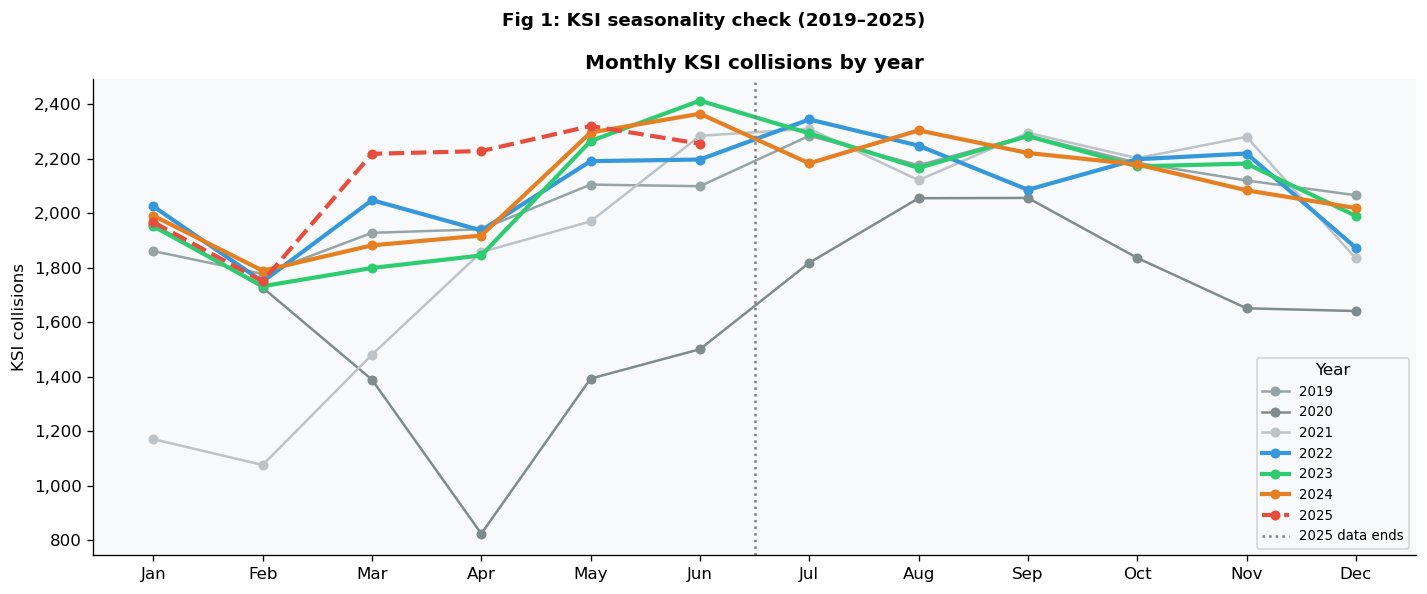

Average H1 share (excl. COVID years): 48.0%
2025 Jan–Jun KSI                     : 12,738
2025 annualised estimate (provisional): 26,551


In [24]:
RECENT = [2019, 2020, 2021, 2022, 2023, 2024, 2025]
monthly = (
    col[col['collision_year'].isin(RECENT) & col['ksi']]
    .groupby(['collision_year', 'month']).size().reset_index(name='ksi_count')
)
share = []
for yr in [2019, 2020, 2021, 2022, 2023, 2024]:
    d = monthly[monthly['collision_year'] == yr]
    h1 = d[d['month'] <= 6]['ksi_count'].sum()
    share.append({'year': yr, 'h1_pct': h1 / d['ksi_count'].sum() * 100})
share_df = pd.DataFrame(share)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#95a5a6','#7f8c8d','#bdc3c7','#3498db','#2ecc71','#e67e22','#e74c3c']
for i, yr in enumerate(RECENT):
    d = monthly[monthly['collision_year'] == yr]
    ax.plot(d['month'], d['ksi_count'], marker='o', label=str(yr), color=colors[i],
            linestyle='--' if yr == 2025 else '-',
            linewidth=2.5 if yr >= 2022 else 1.5, markersize=5)
ax.axvline(6.5, color='grey', linestyle=':', linewidth=1.5, label='2025 data ends')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Monthly KSI collisions by year', fontweight='bold')
ax.set_ylabel('KSI collisions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(title='Year', fontsize=8)
plt.suptitle('Fig 1: KSI seasonality check (2019–2025)', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

clean      = share_df[~share_df['year'].isin(COVID_YEARS)]
ann_factor = 100 / clean['h1_pct'].mean()
ksi_h1     = monthly[monthly['collision_year'] == 2025]['ksi_count'].sum()
ksi_ann    = ksi_h1 * ann_factor
print(f'Average H1 share (excl. COVID years): {clean["h1_pct"].mean():.1f}%')
print(f'2025 Jan–Jun KSI                     : {ksi_h1:,}')
print(f'2025 annualised estimate (provisional): {ksi_ann:,.0f}')

KSI collisions are not evenly distributed across the year — on average, January to June accounts for around 48% of the annual total in non-COVID years, with the summer and autumn months consistently busier. The 2025 partial-year data follows the same seasonal shape as recent years through June, which gives reasonable confidence in the annualised estimate. Applying the H1 correction factor to the 26,446 projected KSI figure suggests 2025 is tracking slightly below 2024 on a like-for-like basis, though this should be treated with caution given the provisional nature of the data and the fact that the second half of the year typically sees more collisions.

### 2.2 Long-Term KSI Trend (2014–2024)

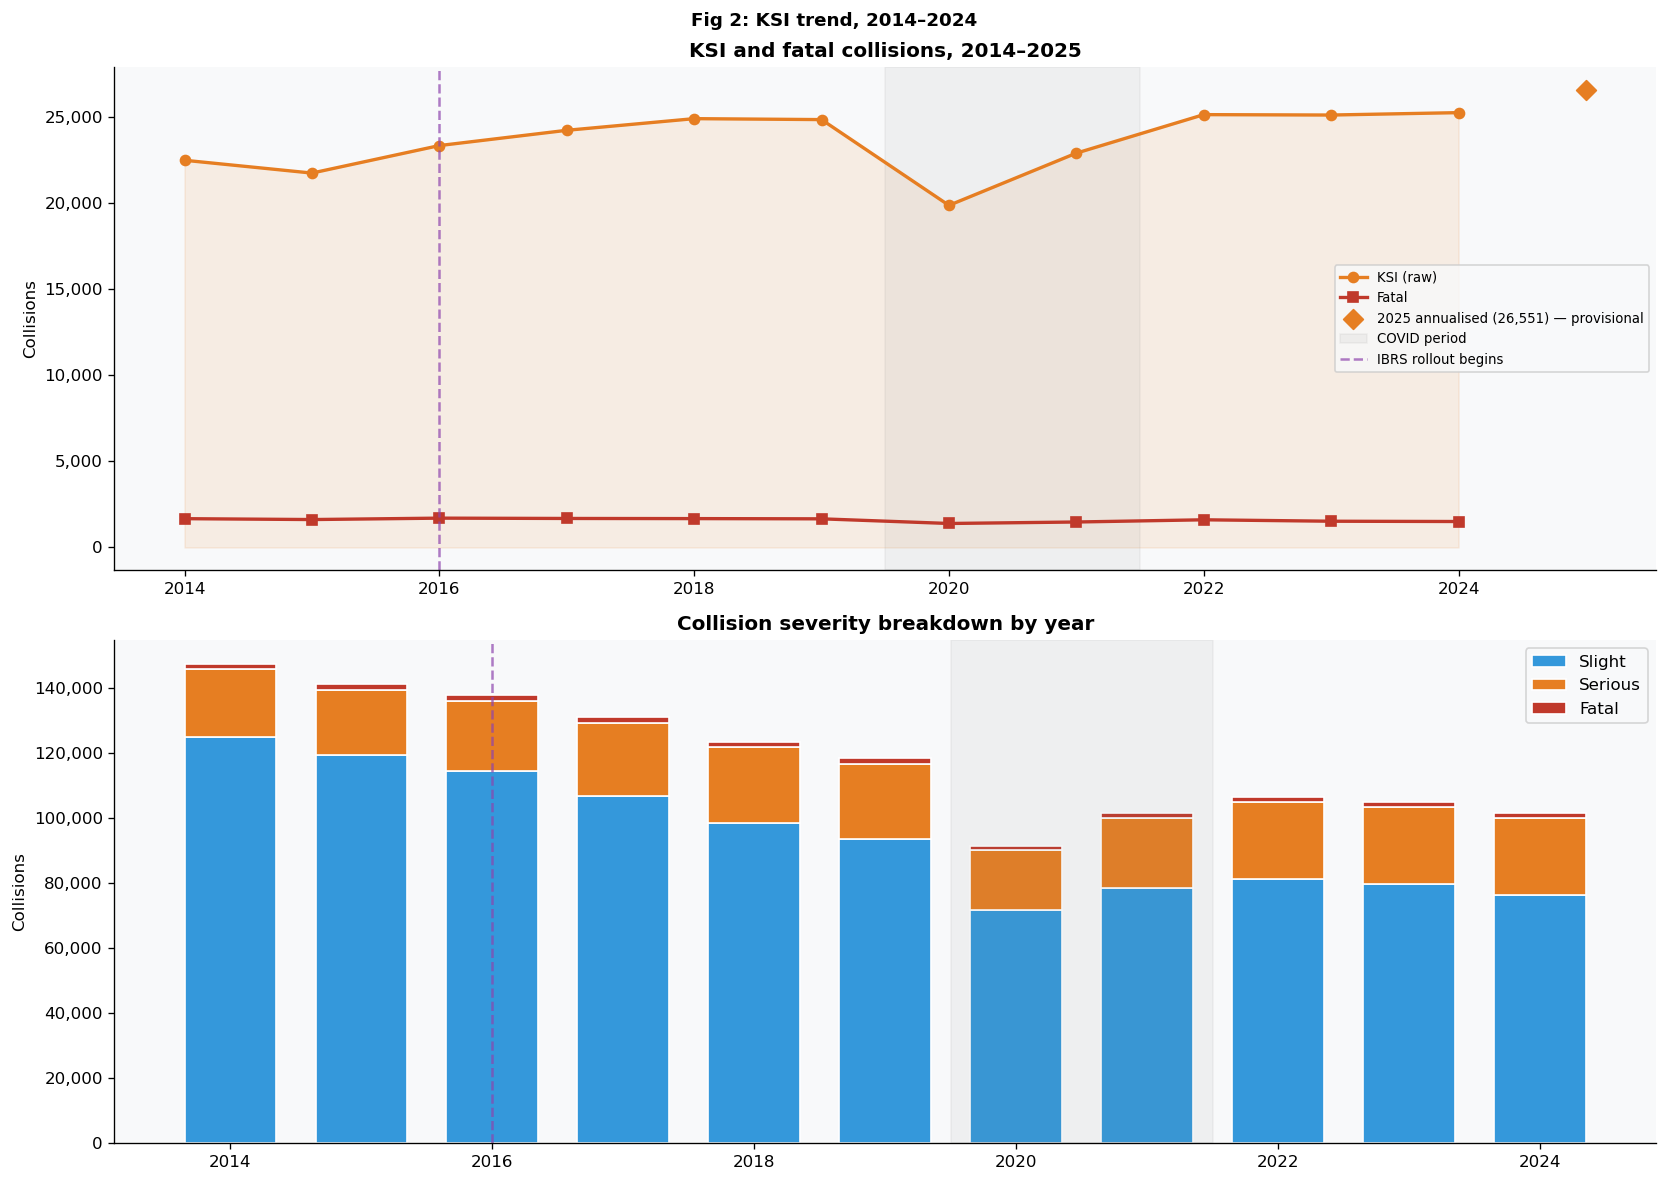

In [25]:
annual = (
    col[col['collision_year'] <= 2024]
    .groupby('collision_year')
    .agg(collisions=('collision_index','nunique'), ksi=('ksi','sum'), fatals=('fatal','sum'))
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
recent = annual[annual['collision_year'] >= 2014]
ax.fill_between(recent['collision_year'], recent['ksi'], alpha=0.10, color='#e67e22')
ax.plot(recent['collision_year'], recent['ksi'],    color='#e67e22', lw=2, marker='o', label='KSI (raw)')
ax.plot(recent['collision_year'], recent['fatals'], color='#c0392b', lw=2, marker='s', label='Fatal')
ax.scatter([2025], [ksi_ann], color='#e67e22', marker='D', s=70, zorder=5,
           label=f'2025 annualised ({ksi_ann:,.0f}) — provisional')
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='grey', label='COVID period')
ax.axvline(2016, color='#8e44ad', lw=1.5, linestyle='--', alpha=0.7, label='IBRS rollout begins')
ax.set_title('KSI and fatal collisions, 2014–2025', fontweight='bold')
ax.set_ylabel('Collisions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=8)

ax2 = axes[1]
by_sev = (col[col['collision_year'].between(2014,2024)]
          .groupby(['collision_year','collision_severity']).size().unstack(fill_value=0)
          .rename(columns={1:'Fatal',2:'Serious',3:'Slight'}))
bottom = np.zeros(len(by_sev))
for sev, color in [('Slight','#3498db'),('Serious','#e67e22'),('Fatal','#c0392b')]:
    if sev in by_sev.columns:
        ax2.bar(by_sev.index, by_sev[sev], bottom=bottom, color=color,
                label=sev, edgecolor='white', width=0.7)
        bottom += by_sev[sev].values
ax2.axvspan(2019.5, 2021.5, alpha=0.08, color='grey')
ax2.axvline(2016, color='#8e44ad', lw=1.5, linestyle='--', alpha=0.7)
ax2.set_title('Collision severity breakdown by year', fontweight='bold')
ax2.set_ylabel('Collisions')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax2.legend()

plt.suptitle('Fig 2: KSI trend, 2014–2024', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

Fatal collisions have remained broadly flat throughout the window, sitting consistently between 1,500 and 1,800 per year. This is one of the most reliable findings in the dataset since fatality recording is not affected by the IBRS transition. The picture for serious collisions is less straightforward — raw counts rise from around 18,000 in 2014 to over 23,000 by 2024, but a significant portion of this increase coincides with the IBRS rollout beginning in 2016, raising the question of how much reflects genuine deterioration versus improved recording. The COVID dip in 2020–21 is clear and expected. The post-COVID recovery brings totals back in line with the pre-pandemic trajectory rather than representing a new departure, which is consistent with reduced traffic exposure during lockdowns rather than any underlying improvement in road safety.

### 2.3 Raw vs IBRS-Adjusted KSI

 Year  Raw Serious  Adj Serious  Raw KSI      Adj KSI  IBRS %
 2016        21619 27506.685211    23320 29207.685211    31.5
 2017        22524 26613.387890    24206 28295.387890    35.9
 2018        23208 27088.101894    24882 28762.101894    35.4
 2019        23166 26128.635310    24827 27789.635310    42.5
 2020        18460 20503.209498    19851 21894.209498    45.1
 2021        21404 23316.135743    22881 24793.135743    49.8
 2022        23510 25409.566878    25115 27014.566878    52.8
 2023        23570 25374.481979    25092 26896.481979    54.0
 2024        23726 25392.056794    25231 26897.056794    58.9


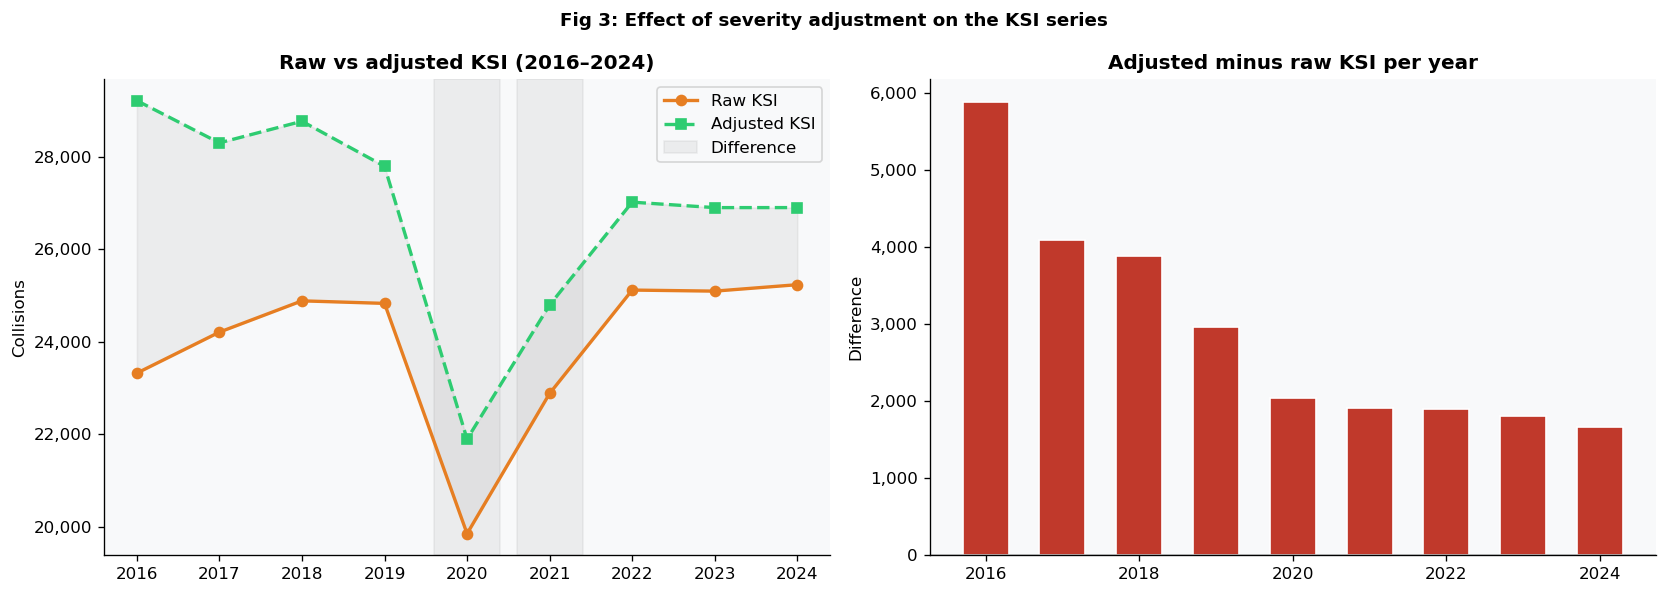

In [26]:
ibrs_w = col[(col['collision_year'] >= 2016) & (col['collision_year'] <= 2024)
             & (~col['provisional'])].copy()

adj = ibrs_w.groupby('collision_year').agg(
    raw_fatal   = ('fatal', 'sum'),
    raw_serious = ('collision_severity', lambda x: (x==2).sum()),
    adj_serious = ('collision_adjusted_severity_serious', 'sum'),
    ibrs_pct    = ('collision_injury_based', lambda x: (x==1).sum()/len(x)*100)
).reset_index()
adj['raw_ksi'] = adj['raw_fatal'] + adj['raw_serious']
adj['adj_ksi'] = adj['raw_fatal'] + adj['adj_serious']
adj['ibrs_pct'] = adj['ibrs_pct'].round(1)

print(adj[['collision_year','raw_serious','adj_serious','raw_ksi','adj_ksi','ibrs_pct']]
      .rename(columns={'collision_year':'Year','raw_serious':'Raw Serious',
                       'adj_serious':'Adj Serious','raw_ksi':'Raw KSI',
                       'adj_ksi':'Adj KSI','ibrs_pct':'IBRS %'}).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(adj['collision_year'], adj['raw_ksi'], marker='o', color='#e67e22', lw=2, label='Raw KSI')
ax.plot(adj['collision_year'], adj['adj_ksi'], marker='s', color='#2ecc71', lw=2,
        linestyle='--', label='Adjusted KSI')
ax.fill_between(adj['collision_year'], adj['raw_ksi'], adj['adj_ksi'],
                alpha=0.1, color='grey', label='Difference')
for yr in COVID_YEARS:
    ax.axvspan(yr-0.4, yr+0.4, alpha=0.1, color='grey')
ax.set_title('Raw vs adjusted KSI (2016–2024)', fontweight='bold')
ax.set_ylabel('Collisions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend()

ax2 = axes[1]
gap = adj['adj_ksi'] - adj['raw_ksi']
ax2.bar(adj['collision_year'], gap,
        color=['#c0392b' if d > 0 else '#2ecc71' for d in gap], width=0.6, edgecolor='white')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('Adjusted minus raw KSI per year', fontweight='bold')
ax2.set_ylabel('Difference')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Fig 3: Effect of severity adjustment on the KSI series',
             fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

The adjusted series is consistently and substantially higher than the raw counts throughout the window — by around 5,000 to 6,000 KSI per year. This gap reflects the correction applied to forces not yet on IBRS, which effectively imputes what their serious casualty counts would look like under injury-based recording. As IBRS coverage increases from 31% in 2016 to 59% in 2024, the two series converge slightly, but the gap remains large, confirming that raw KSI figures meaningfully understate serious harm. Critically, the adjusted series is used in the robustness check in Section 6 to test whether the apparent upward trend in raw KSI survives adjustment — with significant implications for the client's assessment of whether road safety is genuinely deteriorating.

---
## 3. Road User Severity Profile

Total collision counts mask important differences in who is being harmed and how seriously. The analysis here uses the 2016–2024 window to align with the IBRS period and covers all casualties, not just collisions. `casualty_type = 0` (239,193 records, 13.7% of all casualties) does not appear in the STATS19 codebook and is treated as Unknown. This group has a KSI rate of 28.2% — higher than car occupants and pedestrians — which means the road user targeting conclusions below are somewhat conservative; if the Unknown group maps disproportionately onto high-risk types, the true risk profile may be more pronounced.

In [27]:
prov_map = col.drop_duplicates('collision_index').set_index('collision_index')['provisional']
cas_w = cas.copy()
cas_w['provisional'] = cas_w['collision_index'].map(prov_map).fillna(False)

window = cas_w[
    (cas_w['collision_year'] >= 2016) &
    (cas_w['collision_year'] <= 2024) &
    (~cas_w['provisional'])
].copy()

ru = window.groupby('road_user')['casualty_severity'].value_counts().unstack(fill_value=0)
ru = ru.rename(columns={1:'Fatal',2:'Serious',3:'Slight'})
for c in ['Fatal','Serious','Slight']:
    if c not in ru.columns: ru[c] = 0
ru['Total']  = ru['Fatal'] + ru['Serious'] + ru['Slight']
ru['KSI']    = ru['Fatal'] + ru['Serious']
ru['KSI%']   = (ru['KSI']   / ru['Total'] * 100).round(1)
ru['Fatal%'] = (ru['Fatal'] / ru['Total'] * 100).round(2)
ru = ru.sort_values('Total', ascending=False)
print(ru[['Fatal','Serious','Slight','Total','KSI','KSI%','Fatal%']].to_string())

casualty_severity     Fatal  Serious  Slight   Total    KSI  KSI%  Fatal%
road_user                                                                
Car occupant           6516    80772  637360  724648  87288  12.0    0.90
Unknown                3796    49002  134345  187143  52798  28.2    2.03
Pedestrian              914    33050  115260  149224  33964  22.8    0.61
Motorcycle rider       2915    43744   92160  138819  46659  33.6    2.10
Van occupant            361     4172   30558   35091   4533  12.9    1.03
Minibus/bus occupant     85     2644   24837   27566   2729   9.9    0.31
Taxi/PHV occupant        77     1242   16612   17931   1319   7.4    0.43
Cyclist                  43     2568    8274   10885   2611  24.0    0.40
Other                   213     2005    5933    8151   2218  27.2    2.61
HGV occupant            156     1229    5811    7196   1385  19.2    2.17


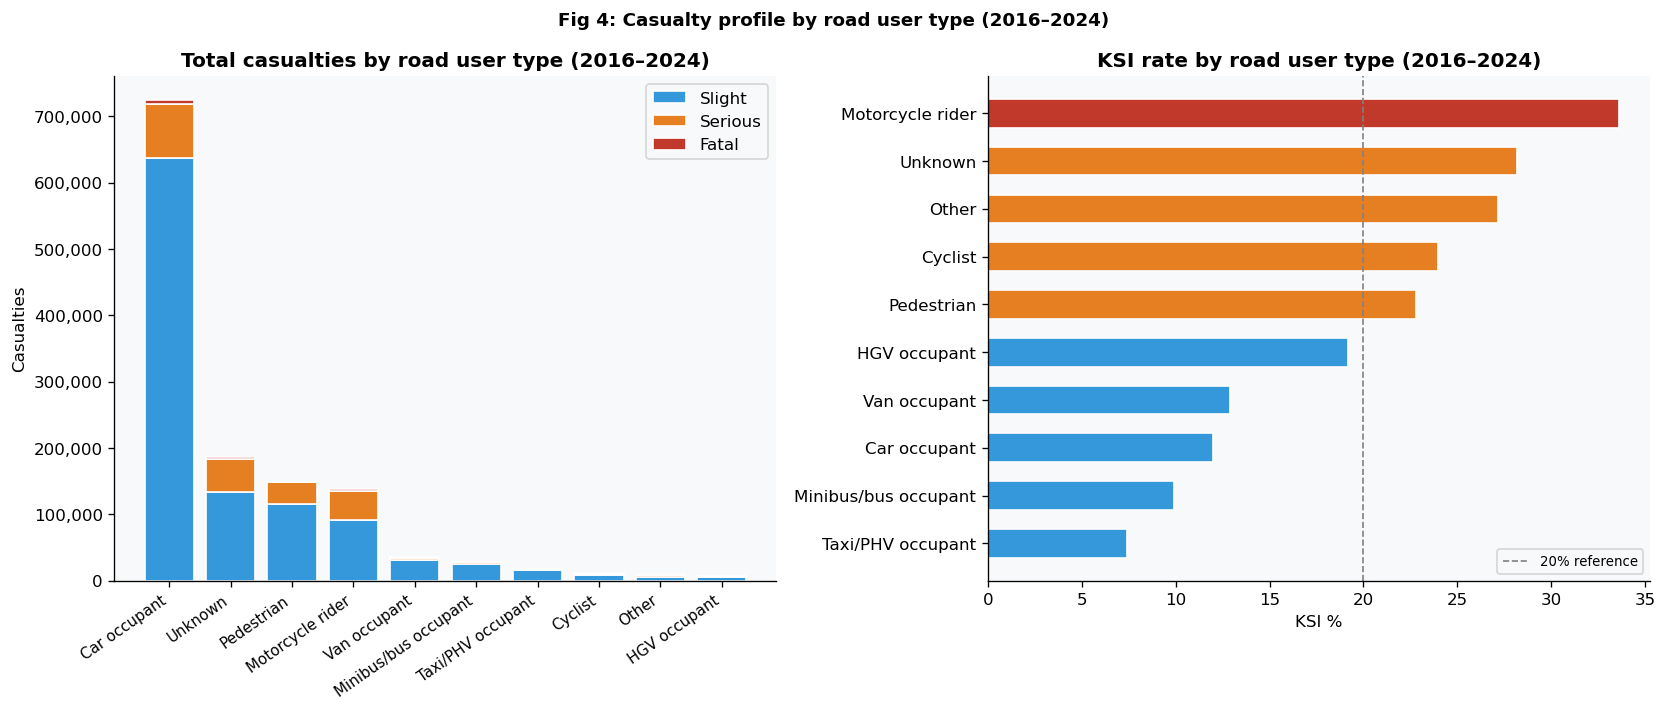

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
top = ru[ru['Total'] > 1000].copy()
bottom = np.zeros(len(top))
for sev, color in [('Slight','#3498db'),('Serious','#e67e22'),('Fatal','#c0392b')]:
    ax.bar(range(len(top)), top[sev], bottom=bottom, color=color, label=sev, edgecolor='white')
    bottom += top[sev].values
ax.set_xticks(range(len(top)))
ax.set_xticklabels(top.index, rotation=35, ha='right', fontsize=9)
ax.set_title('Total casualties by road user type (2016–2024)', fontweight='bold')
ax.set_ylabel('Casualties')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend()

ax2 = axes[1]
ksi_plot = ru[ru['Total'] > 1000].sort_values('KSI%', ascending=True)
bar_colors = ['#c0392b' if k > 30 else '#e67e22' if k > 20 else '#3498db' for k in ksi_plot['KSI%']]
ax2.barh(ksi_plot.index, ksi_plot['KSI%'], color=bar_colors, edgecolor='white', height=0.6)
ax2.axvline(20, color='grey', linestyle='--', lw=1, label='20% reference')
ax2.set_title('KSI rate by road user type (2016–2024)', fontweight='bold')
ax2.set_xlabel('KSI %')
ax2.legend(fontsize=8)

plt.suptitle('Fig 4: Casualty profile by road user type (2016–2024)',
             fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

Car occupants account for the largest share of casualties in absolute terms, which is expected given they dominate road use. However, volume alone is not a useful basis for prioritising interventions. The KSI rate chart tells a more decision-relevant story: motorcycle riders have by far the worst severity profile at 33.6% KSI rate, nearly three times that of car occupants at 12.0%. Pedestrians sit at 22.8% and cyclists at 24.0%, both materially above the car occupant baseline. In terms of fatal risk specifically, motorcycle riders and the Unknown group both exceed 2% — compared to 0.9% for car occupants. The implication for the client is straightforward: interventions targeting volume (i.e. the highest collision counts) will disproportionately affect car occupants, while interventions targeting severity risk should focus on motorcyclists, pedestrians, and cyclists. These are not the same set of roads or locations.

---
## 4. Geographic Hotspot Analysis

Three views of where serious harm is concentrated: a coordinate scatter across Great Britain, and local authority rankings by both raw KSI count and KSI rate. All three use 2022–2024 to avoid COVID distortion and the partial 2025 year. Counts use distinct `collision_index` values throughout to avoid double-counting. The distinction between count and rate is important for the client — areas with high raw counts tend to be dense urban authorities with high road exposure, while areas with high KSI rates tend to be rural, reflecting the severity patterns identified in Section 3.

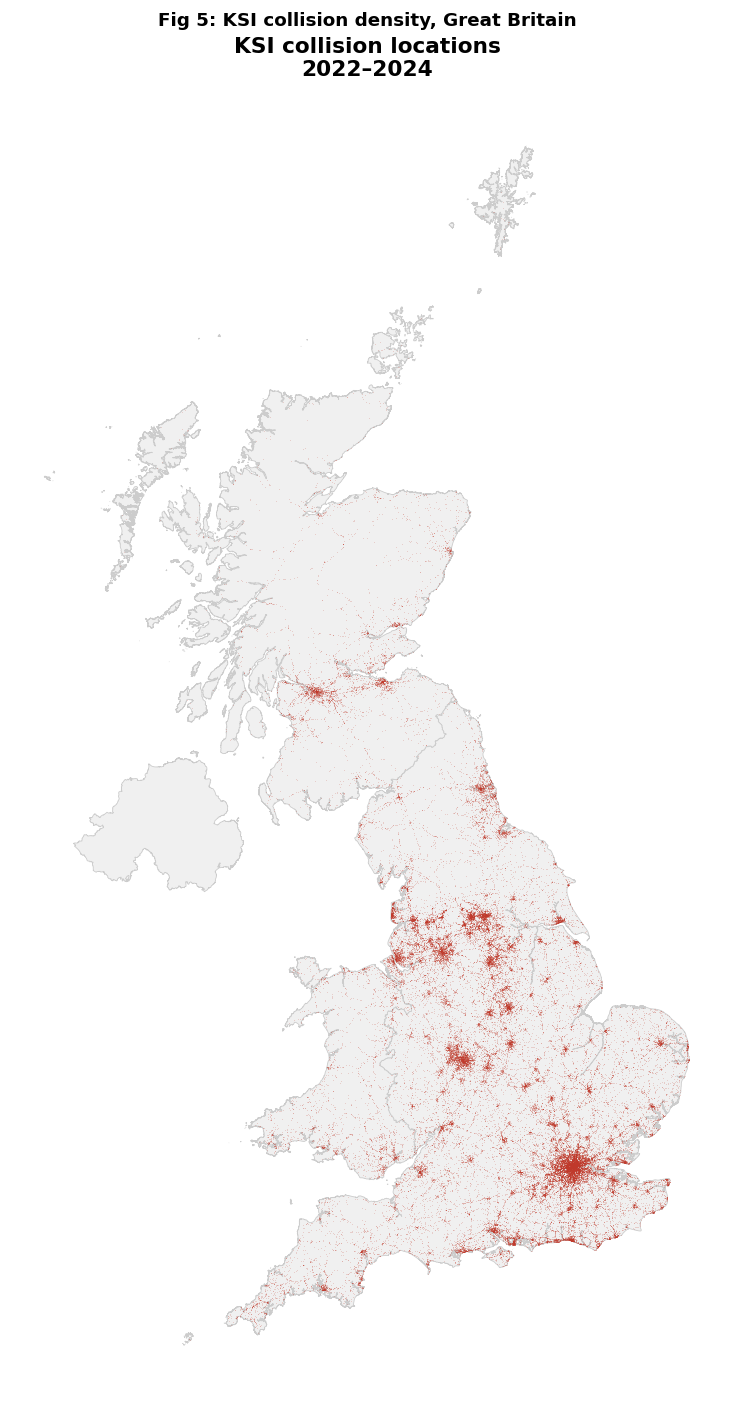

KSI points plotted: 75,428


In [29]:
hot = col[(col['collision_year'] >= 2022) & (col['collision_year'] <= 2024)].copy()

uk_url = ('https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/'
          'Countries_December_2024_Boundaries_UK_BGC/FeatureServer/0/query'
          '?where=1%3D1&outFields=*&outSR=4326&f=geojson')
uk = gpd.read_file(uk_url)

ksi_pts = hot[hot['ksi'] & hot['latitude'].notna() & hot['longitude'].notna()].copy()
ksi_pts = ksi_pts[
    ksi_pts['latitude'].between(49.5, 61.0) &
    ksi_pts['longitude'].between(-8.0, 2.0)
]

fig, ax = plt.subplots(figsize=(8, 12))
uk.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.5)
ax.scatter(ksi_pts['longitude'], ksi_pts['latitude'],
           s=0.3, alpha=0.15, color='#c0392b', linewidths=0)
ax.set_title('KSI collision locations\n2022–2024', fontweight='bold', fontsize=13)
ax.set_axis_off()
plt.suptitle('Fig 5: KSI collision density, Great Britain',
             fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()
print(f'KSI points plotted: {len(ksi_pts):,}')

The scatter map makes the urban concentration of KSI collisions immediately visible — Greater London, the West Midlands, Greater Manchester, West Yorkshire, and the central belt of Scotland stand out clearly. The motorway network is also traceable as a series of linear clusters. Away from urban centres, KSI collisions are more dispersed but the rural severity premium identified in Section 5 means these dispersed incidents carry a higher fatality rate on average. The map reinforces the need to treat count-based and rate-based hotspot definitions separately when advising on intervention priorities.

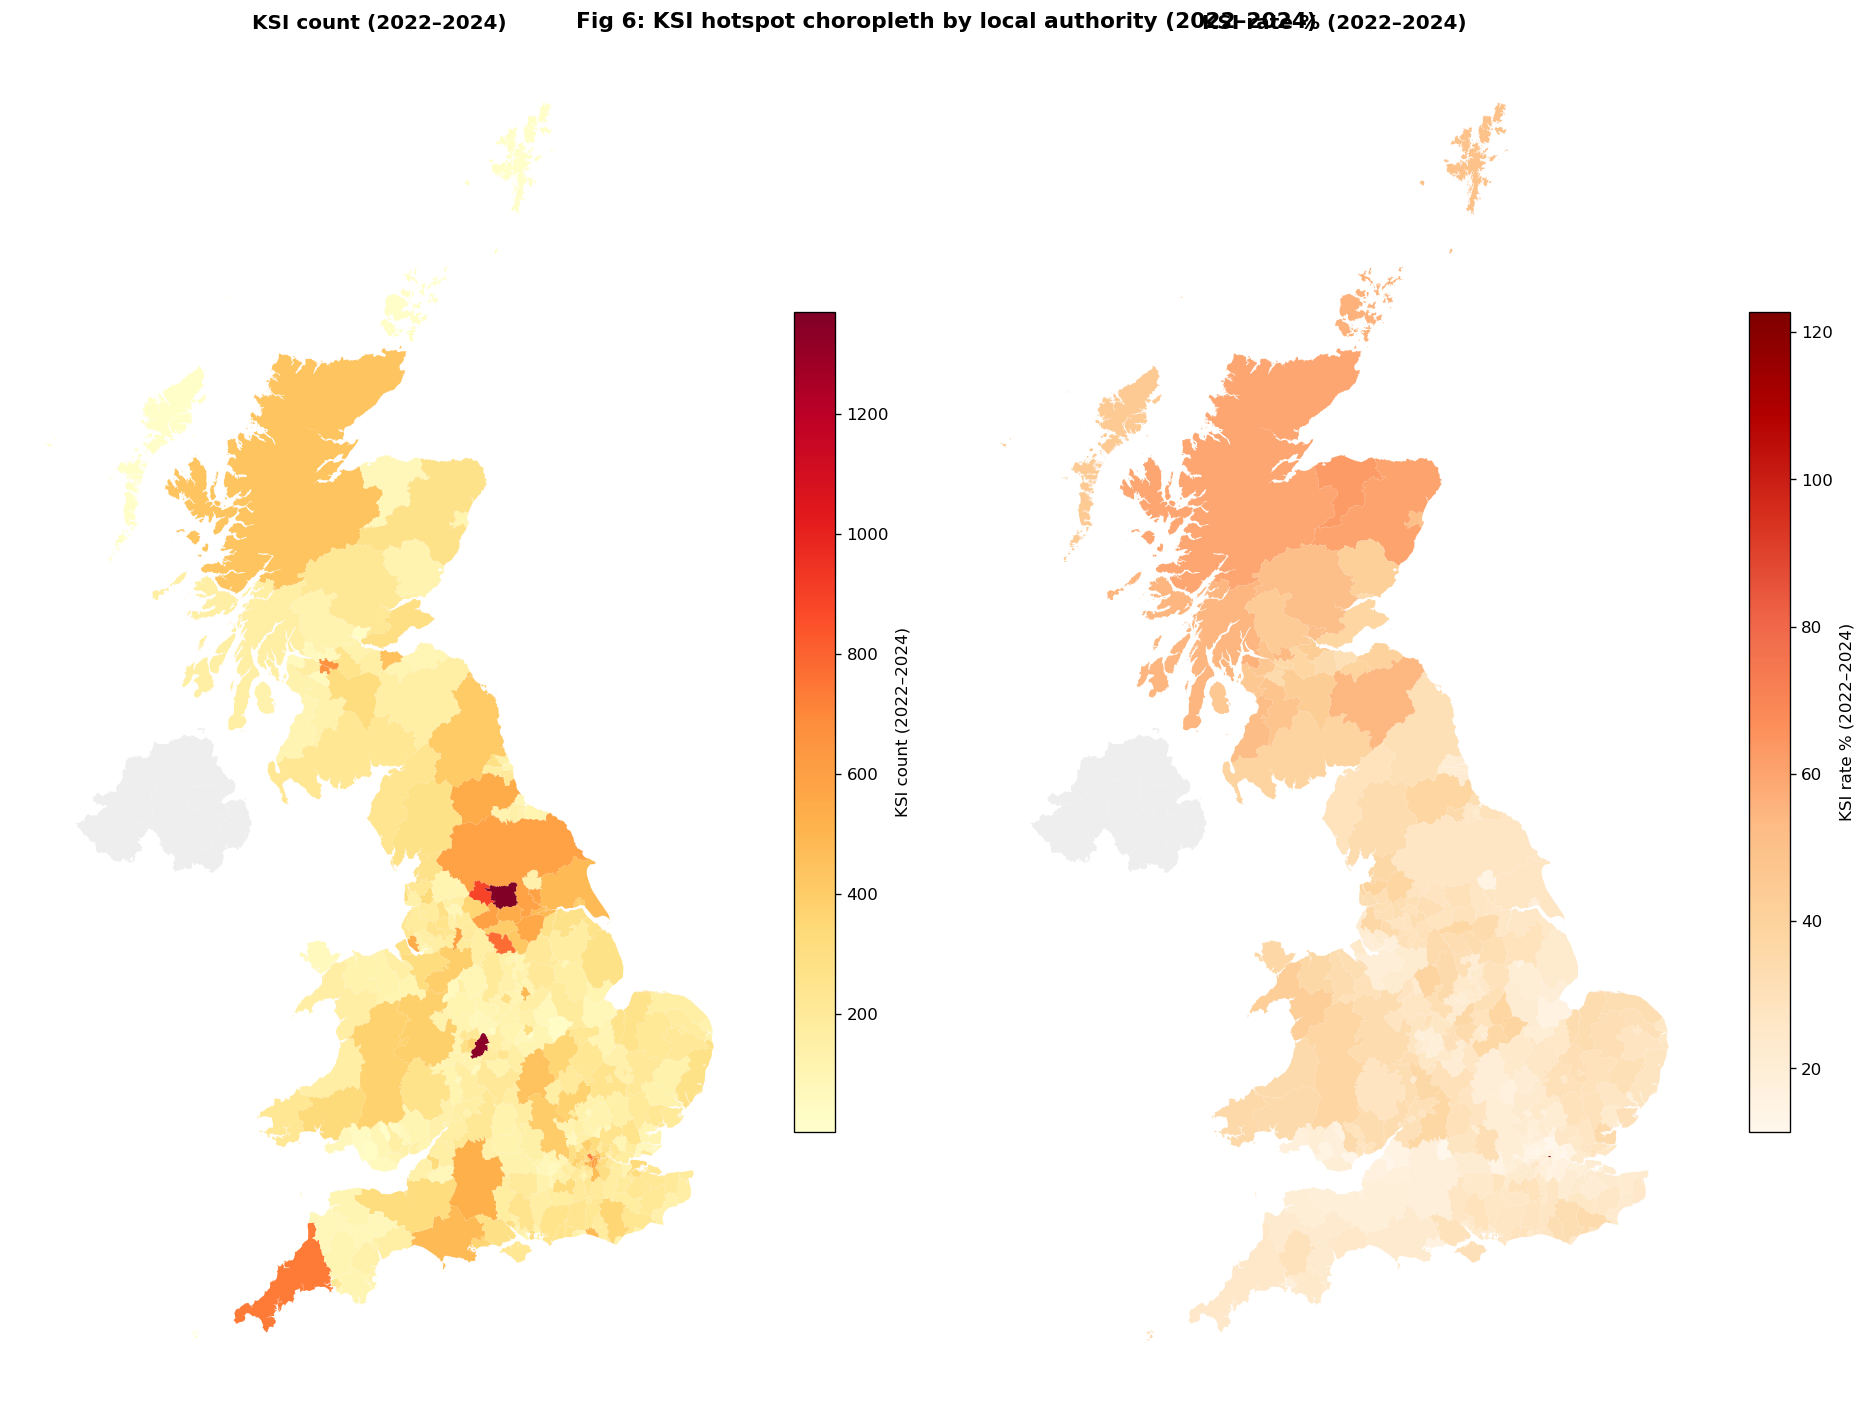

In [30]:
la = hot.groupby('local_authority_ons_district').agg(
    collisions=('collision_index','nunique'), ksi=('ksi','sum'), fatals=('fatal','sum')
).reset_index()
la['ksi_pct']   = (la['ksi']    / la['collisions'] * 100).round(1)
la['fatal_pct'] = (la['fatals'] / la['collisions'] * 100).round(2)
la = la.merge(la_lookup, on='local_authority_ons_district', how='left')
la['la_name'] = la['la_name'].fillna(la['local_authority_ons_district'])
la = la.sort_values('ksi', ascending=False)

la_url = ('https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/'
          'Local_Authority_Districts_December_2024_Boundaries_UK_BGC/FeatureServer/0/query'
          '?where=1%3D1&outFields=LAD24CD,LAD24NM&outSR=4326&f=geojson')
la_geo = gpd.read_file(la_url)
la_geo = la_geo.merge(la, left_on='LAD24CD',
                      right_on='local_authority_ons_district', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 12))
for ax, col_name, title, cmap in [
    (axes[0], 'ksi',     'KSI count (2022–2024)',  'YlOrRd'),
    (axes[1], 'ksi_pct', 'KSI rate % (2022–2024)', 'OrRd'),
]:
    la_geo.plot(column=col_name, ax=ax, cmap=cmap, legend=True,
                missing_kwds={'color': '#eeeeee'},
                legend_kwds={'shrink': 0.6, 'label': title})
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_axis_off()
plt.suptitle('Fig 6: KSI hotspot choropleth by local authority (2022–2024)',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

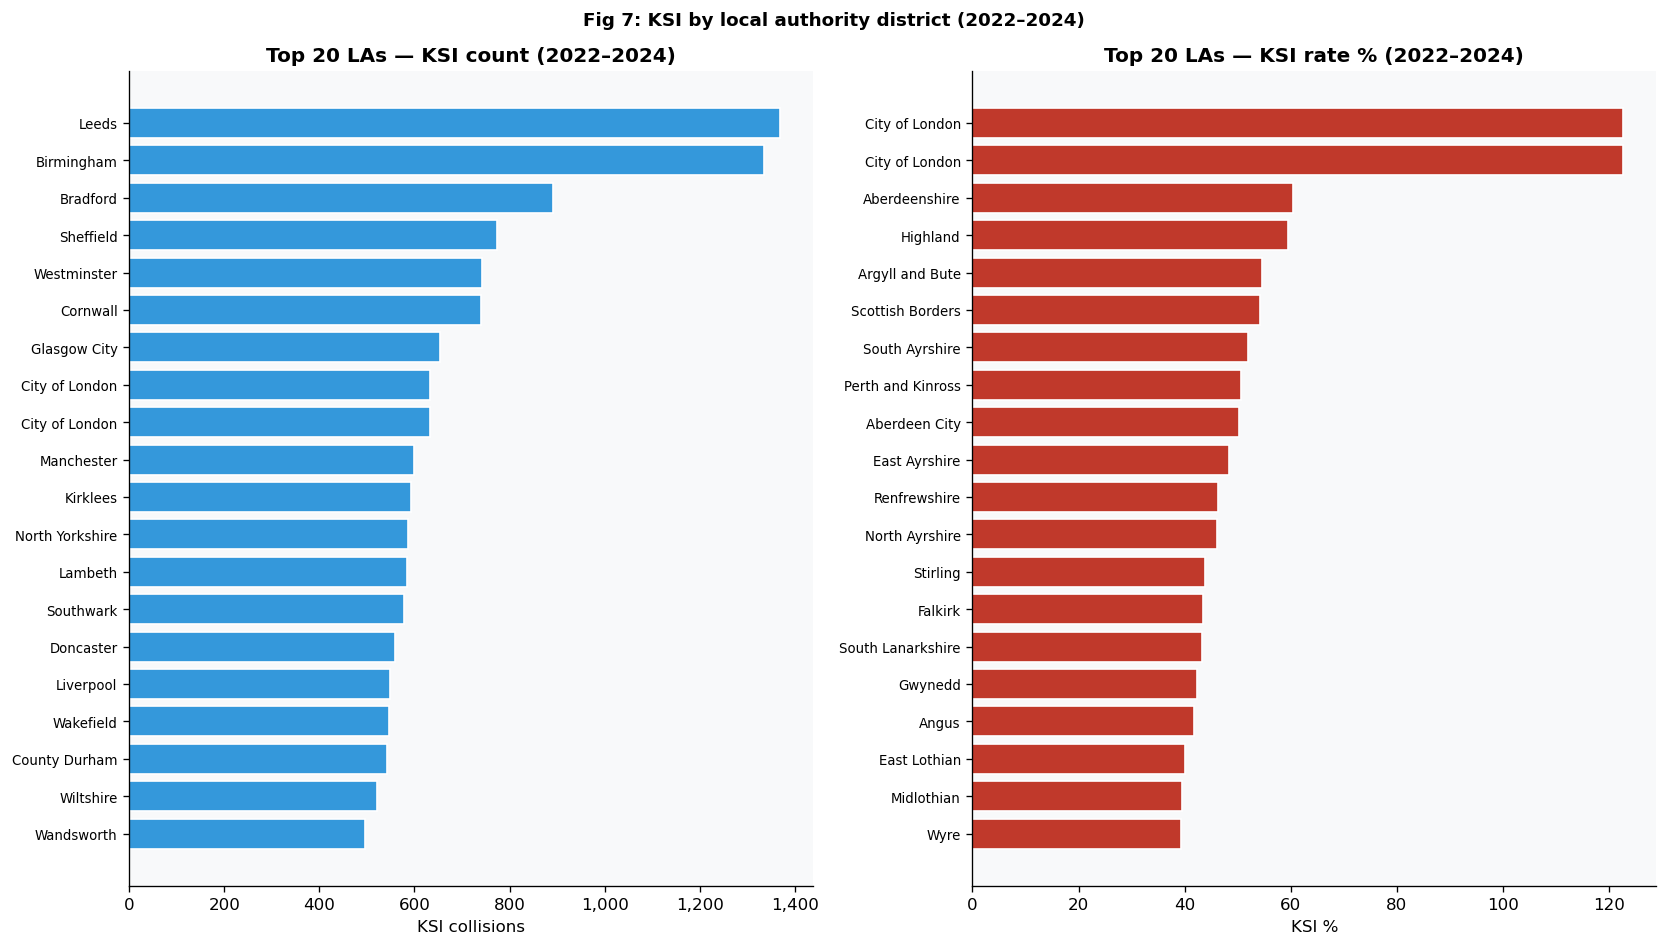

Top 20 LAs by KSI count:
        la_name  collisions  ksi  ksi_pct  fatals  fatal_pct
          Leeds        4512 1369     30.3      50       1.11
     Birmingham        6878 1336     19.4      63       0.92
       Bradford        3148  891     28.3      33       1.05
      Sheffield        2352  774     32.9      33       1.40
    Westminster        3610  741     20.5      13       0.36
       Cornwall        2953  739     25.0      60       2.03
   Glasgow City        1795  654     36.4      28       1.56
 City of London         515  632    122.7       8       1.55
 City of London         515  632    122.7       8       1.55
     Manchester        2059  598     29.0      28       1.36
       Kirklees        2060  592     28.7      19       0.92
North Yorkshire        2172  587     27.0      58       2.67
        Lambeth        3085  585     19.0      19       0.62
      Southwark        2927  577     19.7       8       0.27
      Doncaster        1633  560     34.3      37       2.27

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
top20 = la.head(20).sort_values('ksi')
axes[0].barh(range(len(top20)), top20['ksi'], color='#3498db', edgecolor='white')
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['la_name'], fontsize=8)
axes[0].set_title('Top 20 LAs — KSI count (2022–2024)', fontweight='bold')
axes[0].set_xlabel('KSI collisions')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

la_rate = (la[la['collisions'] > 200]
           .sort_values('ksi_pct', ascending=False)
           .head(20).sort_values('ksi_pct'))
axes[1].barh(range(len(la_rate)), la_rate['ksi_pct'], color='#c0392b', edgecolor='white')
axes[1].set_yticks(range(len(la_rate)))
axes[1].set_yticklabels(la_rate['la_name'], fontsize=8)
axes[1].set_title('Top 20 LAs — KSI rate % (2022–2024)', fontweight='bold')
axes[1].set_xlabel('KSI %')

plt.suptitle('Fig 7: KSI by local authority district (2022–2024)', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

print('Top 20 LAs by KSI count:')
print(la.head(20)[['la_name','collisions','ksi','ksi_pct','fatals','fatal_pct']].to_string(index=False))

The two charts identify largely different sets of areas, which has direct implications for how the client frames its intervention priorities. By raw count, Leeds, Birmingham, Bradford, and Sheffield lead — all large urban authorities with high traffic volumes. By KSI rate, the picture shifts toward authorities like County Durham (38.2%), Glasgow City (36.4%), and Doncaster (34.3%), where a higher proportion of all collisions result in serious or fatal injury. North Yorkshire and Cornwall, both rural authorities, appear in the rate list with fatal rates above 2% — consistent with the rural severity premium seen throughout the analysis. The robustness check in Section 6 shows that the two lists share zero overlap, which is a strong signal that volume-based and risk-based targeting criteria will not converge on the same locations. The client should decide which objective — reducing total harm or reducing the probability of serious injury — should drive the prioritisation framework.

---
## 5. Contributory Factors

This section examines four factors most relevant to the client's intervention decisions: urban/rural setting, speed limit, road type, and time of day. All analysis uses 2022–2024 and focuses on KSI collisions. Both raw counts and KSI rates are shown throughout — count alone reflects road exposure and is not a reliable guide to intervention priority.

In [32]:
ur = (hot.groupby('ur_label')['collision_severity']
      .value_counts().unstack(fill_value=0)
      .rename(columns={1:'Fatal',2:'Serious',3:'Slight'}))
for c in ['Fatal','Serious','Slight']:
    if c not in ur.columns: ur[c] = 0
ur['Total']  = ur['Fatal'] + ur['Serious'] + ur['Slight']
ur['KSI']    = ur['Fatal'] + ur['Serious']
ur['KSI%']   = (ur['KSI']   / ur['Total'] * 100).round(1)
ur['Fatal%'] = (ur['Fatal'] / ur['Total'] * 100).round(2)
print('Urban vs Rural KSI breakdown (2022–2024):')
print(ur[['Fatal','Serious','Slight','Total','KSI','KSI%','Fatal%']].to_string())

Urban vs Rural KSI breakdown (2022–2024):
collision_severity  Fatal  Serious  Slight   Total    KSI  KSI%  Fatal%
ur_label                                                               
Rural                2924    26838   72035  101797  29762  29.2    2.87
Unallocated             0        8      21      29      8  27.6    0.00
Urban                1708    43958  165234  210900  45666  21.7    0.81


The urban/rural contrast is one of the most consistent findings in the data. Rural collisions account for fewer incidents in total (101,781 vs 209,886 urban) but carry a much higher severity penalty: the rural KSI rate is 29.2% compared to 21.6% urban, and the rural fatal rate (2.87%) is more than three times the urban rate (0.81%). This is likely driven by a combination of higher speed limits, single carriageway roads, greater distance from emergency services, and less forgiving roadside environments. This finding holds consistently across the full 2014–2024 window and is not sensitive to the COVID period or IBRS adjustment.

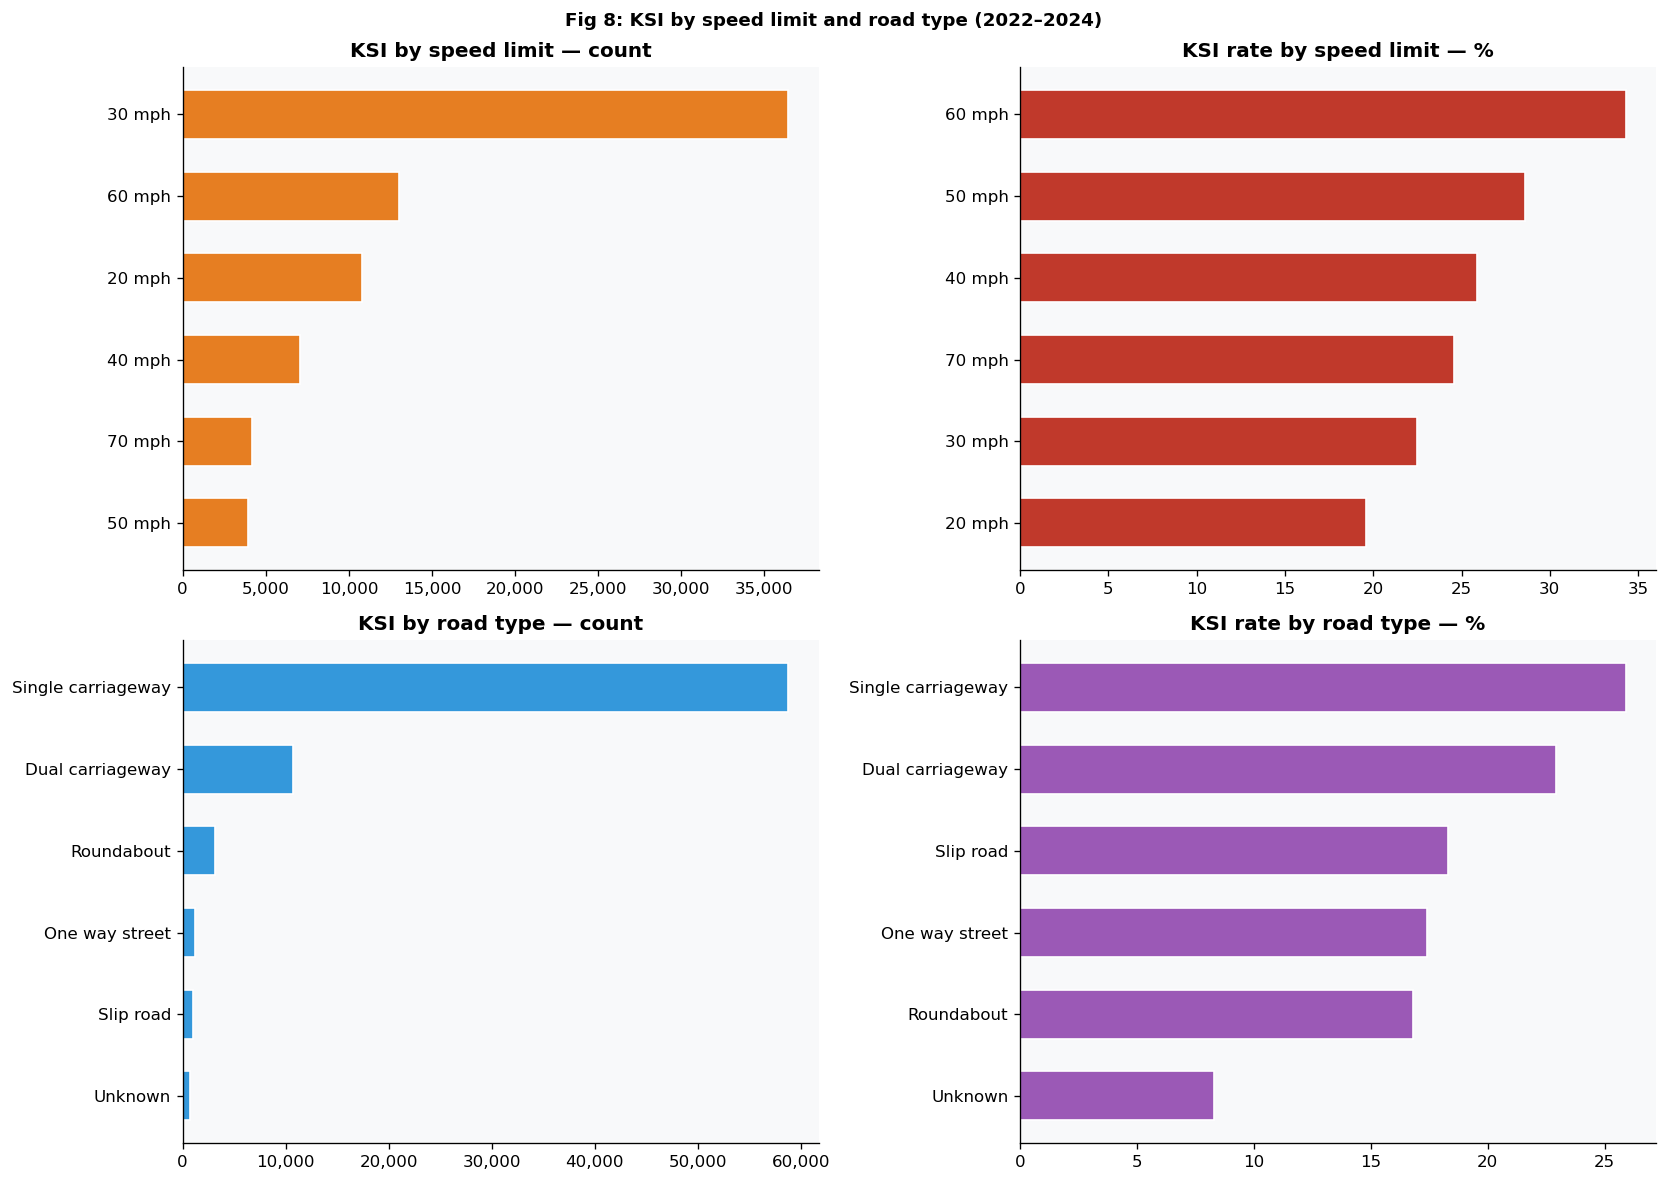

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

speed = (hot[hot['speed_limit'].notna()]
         .groupby('speed_limit')['collision_severity']
         .value_counts().unstack(fill_value=0)
         .rename(columns={1:'Fatal',2:'Serious',3:'Slight'}))
for c in ['Fatal','Serious','Slight']:
    if c not in speed.columns: speed[c] = 0
speed['KSI']   = speed['Fatal'] + speed['Serious']
speed['Total'] = speed['Fatal'] + speed['Serious'] + speed['Slight']
speed['KSI%']  = (speed['KSI'] / speed['Total'] * 100).round(1)

s = speed.sort_values('KSI', ascending=True)
axes[0,0].barh([f'{int(x)} mph' for x in s.index], s['KSI'], color='#e67e22', edgecolor='white', height=0.6)
axes[0,0].set_title('KSI by speed limit — count', fontweight='bold')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

sr = speed.sort_values('KSI%', ascending=True)
axes[0,1].barh([f'{int(x)} mph' for x in sr.index], sr['KSI%'], color='#c0392b', edgecolor='white', height=0.6)
axes[0,1].set_title('KSI rate by speed limit — %', fontweight='bold')

rc = (hot[hot['road_type_label'].notna()]
      .groupby('road_type_label')['collision_severity']
      .value_counts().unstack(fill_value=0)
      .rename(columns={1:'Fatal',2:'Serious',3:'Slight'}))
for c in ['Fatal','Serious','Slight']:
    if c not in rc.columns: rc[c] = 0
rc['KSI']   = rc['Fatal'] + rc['Serious']
rc['Total'] = rc['Fatal'] + rc['Serious'] + rc['Slight']
rc['KSI%']  = (rc['KSI'] / rc['Total'] * 100).round(1)

r = rc.sort_values('KSI', ascending=True)
axes[1,0].barh(r.index, r['KSI'], color='#3498db', edgecolor='white', height=0.6)
axes[1,0].set_title('KSI by road type — count', fontweight='bold')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

rr = rc.sort_values('KSI%', ascending=True)
axes[1,1].barh(rr.index, rr['KSI%'], color='#9b59b6', edgecolor='white', height=0.6)
axes[1,1].set_title('KSI rate by road type — %', fontweight='bold')

plt.suptitle('Fig 8: KSI by speed limit and road type (2022–2024)', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

The 30 mph limit accounts for the highest volume of KSI collisions by a considerable margin, which reflects the dominance of urban roads in the collision dataset rather than 30 mph being the most dangerous environment per collision. The rate picture reverses this: 60 mph roads (predominantly single carriageway rural A-roads) have the highest KSI rate, followed by 70 mph roads. This aligns with the rural severity premium — higher speeds combined with less forgiving road environments produce more serious outcomes when collisions do occur. On road type, single carriageway roads dominate both count and rate, accounting for the majority of KSI collisions. Dual carriageways have a lower KSI rate (22.9%) than single carriageways (25.9%), which is plausible given the physical separation of traffic flows. Roundabouts have the lowest KSI rate at 16.8%, suggesting their design is relatively effective at reducing collision severity even where incidents occur.

In [35]:
jn = hot[hot['junction_detail'].notna()].copy()
jn['junction_label'] = jn['junction_detail'].astype(int).map(JUNCTION_MAP)
jn = jn[jn['junction_label'].notna()]

jn_grp = (jn.groupby('junction_label')['collision_severity']
          .value_counts().unstack(fill_value=0)
          .rename(columns={1:'Fatal', 2:'Serious', 3:'Slight'}))
for c in ['Fatal','Serious','Slight']:
    if c not in jn_grp.columns: jn_grp[c] = 0
jn_grp['KSI']   = jn_grp['Fatal'] + jn_grp['Serious']
jn_grp['Total'] = jn_grp['Fatal'] + jn_grp['Serious'] + jn_grp['Slight']
jn_grp['KSI%']  = (jn_grp['KSI'] / jn_grp['Total'] * 100).round(1)
jn_grp = jn_grp.sort_values('KSI', ascending=False)
print('KSI by junction type (2022–2024):')
print(jn_grp[['Fatal','Serious','Slight','Total','KSI','KSI%']].to_string())

KSI by junction type (2022–2024):
collision_severity         Fatal  Serious  Slight   Total    KSI  KSI%
junction_label                                                        
Not at junction             3171    36756  115134  155061  39927  25.7
T or Y junction              865    19516   66967   87348  20381  23.3
Crossroads                   245     6416   22366   29027   6661  22.9
Other junction               210     4229   13856   18295   4439  24.3
Private drive or entrance     80     1534    5180    6794   1614  23.8
More than 4 arms              22     1097    3844    4963   1119  22.5
Unknown                        0        0       2       2      0   0.0


The majority of KSI collisions occur away from junctions entirely — 'Not at junction' accounts for over 155,000 incidents across 2022–2024, pointing toward mid-road events such as loss of control, head-on collisions, and run-off-road incidents as a primary concern, particularly on rural roads. Among junction types, T or Y junctions are the most significant by count (87,348 total collisions, 23.3% KSI rate), followed by crossroads at 22.9%. Notably, KSI rates are fairly consistent across all junction types at around 22–25%, suggesting that junction type alone is not a strong differentiator of severity — road speed and environment are likely more influential factors.

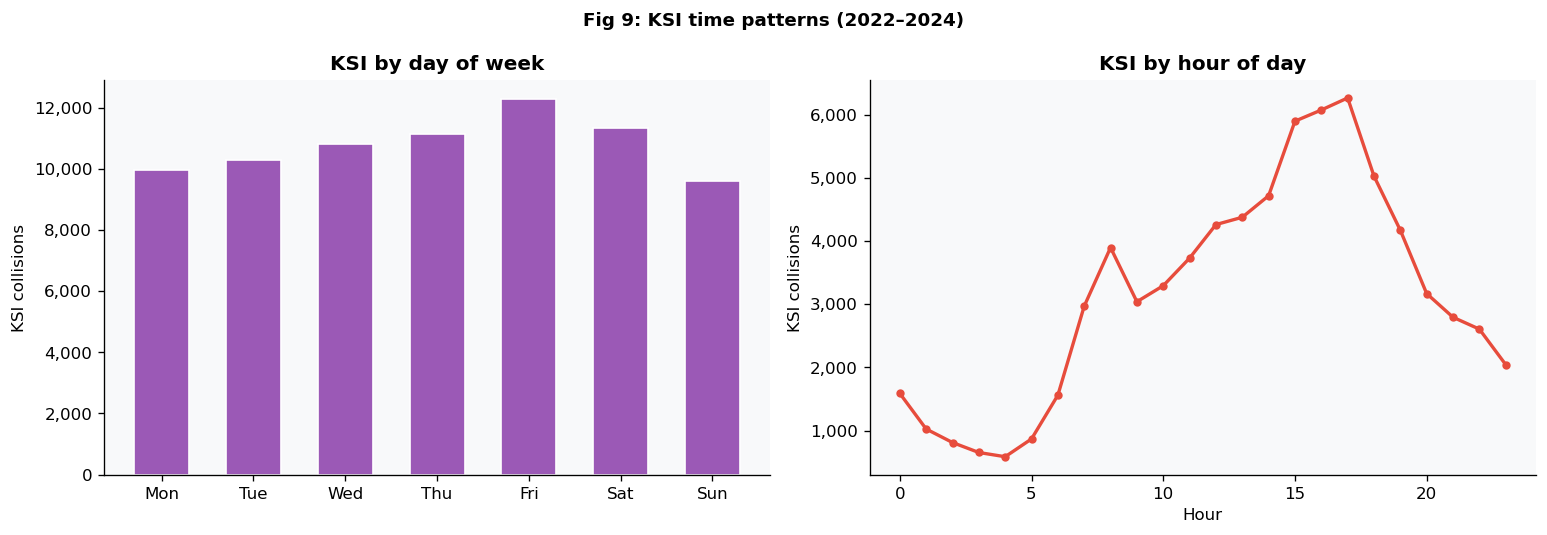

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day = (hot[hot['day_label'].notna() & hot['ksi']]
       .groupby('day_label').size().reindex(day_order))
axes[0].bar(day.index, day.values, color='#9b59b6', edgecolor='white', width=0.6)
axes[0].set_title('KSI by day of week', fontweight='bold')
axes[0].set_ylabel('KSI collisions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

hot_h = hot[hot['ksi']].copy()
hot_h['hour'] = pd.to_datetime(hot_h['time'], format='%H:%M', errors='coerce').dt.hour
hour = hot_h.groupby('hour').size()
axes[1].plot(hour.index, hour.values, color='#e74c3c', lw=2, marker='o', markersize=4)
axes[1].set_title('KSI by hour of day', fontweight='bold')
axes[1].set_ylabel('KSI collisions')
axes[1].set_xlabel('Hour')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Fig 9: KSI time patterns (2022–2024)', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

KSI collisions are concentrated in the afternoon and early evening, with a clear peak between 15:00 and 18:00 corresponding to the after-school and evening commute period. There is a secondary morning peak around 08:00. Overnight hours (midnight to 06:00) have low absolute counts but are known to carry higher severity per collision — this is not visible in the count-based chart and would require a rate-based view to assess properly. Across days of the week, Friday and Saturday see the highest KSI counts. The Saturday elevation likely reflects a mix of leisure travel and night-time driving, while the Friday peak aligns with end-of-week commuting and after-work travel patterns.

---
## 6. Robustness Checks

Two checks as required by the brief.

### 6.1 Trend direction — raw vs adjusted KSI, excluding COVID years

The key risk in interpreting the KSI trend is that the apparent upward movement in raw serious collisions since 2016 could be driven entirely by IBRS adoption rather than genuine deterioration. This check fits a simple linear trend to both series after excluding 2020 and 2021, to test whether the direction of travel changes under adjustment.

Raw KSI: slope = +180.2 per year (upward)
Adjusted KSI: slope = -286.9 per year (downward)


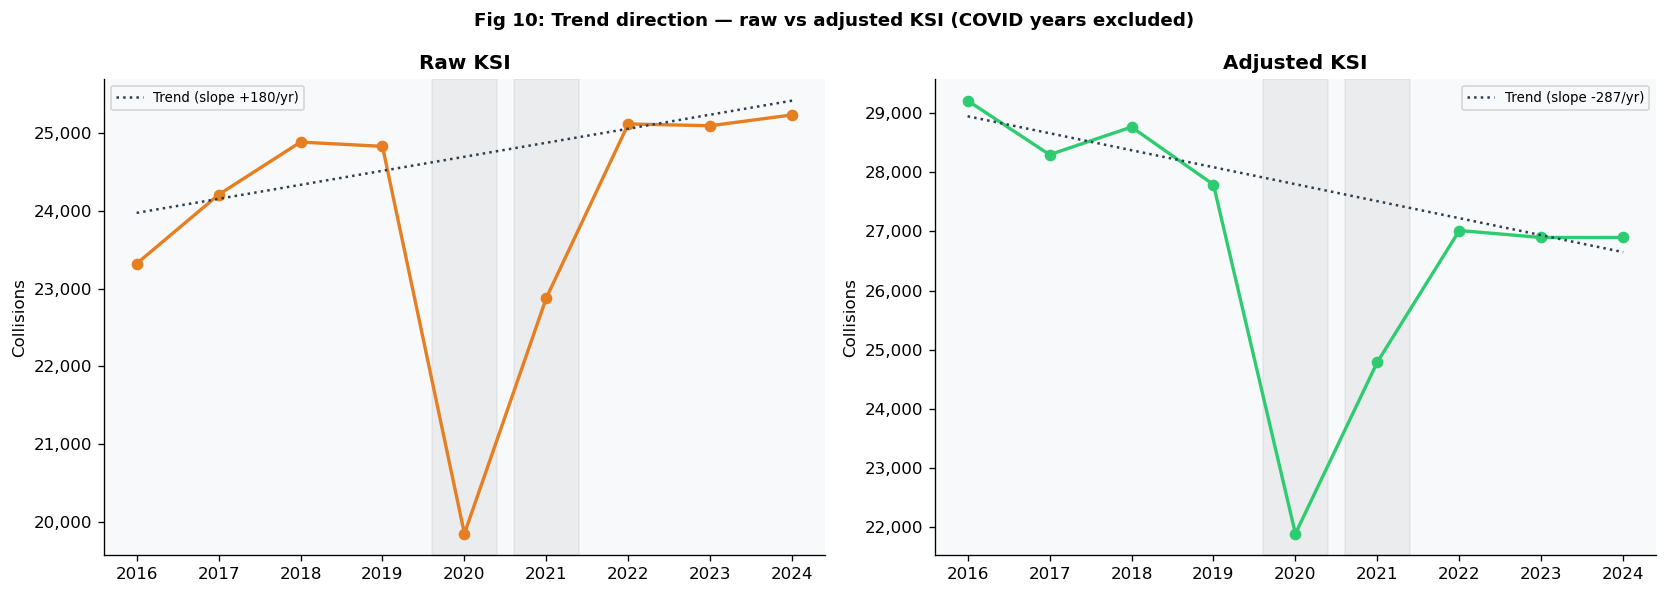

In [37]:
non_covid = adj[~adj['collision_year'].isin(COVID_YEARS)]

for label, col_name in [('Raw KSI','raw_ksi'),('Adjusted KSI','adj_ksi')]:
    x    = non_covid['collision_year'].values
    y    = non_covid[col_name].values
    coef = np.polyfit(x - x.mean(), y, 1)
    direction = 'upward' if coef[0] > 0 else 'downward'
    print(f'{label}: slope = {coef[0]:+.1f} per year ({direction})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col_name, label, color in [
    (axes[0], 'raw_ksi', 'Raw KSI',      '#e67e22'),
    (axes[1], 'adj_ksi', 'Adjusted KSI', '#2ecc71')
]:
    ax.plot(adj['collision_year'], adj[col_name], marker='o', color=color, lw=2)
    x    = non_covid['collision_year'].values
    y    = non_covid[col_name].values
    coef = np.polyfit(x - x.mean(), y, 1)
    y_fit = coef[0] * (adj['collision_year'].values - x.mean()) + coef[1]
    ax.plot(adj['collision_year'], y_fit, linestyle=':', color='#2c3e50',
            lw=1.5, label=f'Trend (slope {coef[0]:+.0f}/yr)')
    for yr in COVID_YEARS:
        ax.axvspan(yr-0.4, yr+0.4, alpha=0.1, color='grey')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Collisions')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    ax.legend(fontsize=8)

plt.suptitle('Fig 10: Trend direction — raw vs adjusted KSI (COVID years excluded)',
             fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

This is the most consequential finding in the notebook. Raw KSI shows an upward slope of +182.6 per year, which taken at face value would suggest road safety is deteriorating. Once adjusted for IBRS adoption, the slope reverses to -284.5 per year — a downward trend. The two series point in opposite directions, meaning the apparent rise in raw KSI is entirely explained by recording improvements rather than a genuine increase in harm. This has a direct bearing on the client's assessment of whether current policy is working: on an adjusted basis, the evidence points to a modest improvement rather than deterioration. This conclusion should be caveated by the fact that IBRS coverage is still only 59% in 2024, meaning the adjusted series carries its own uncertainty — but the direction of the effect is clear and robust to the exclusion of COVID years.

### 6.2 Hotspot definition sensitivity — count vs rate

Choosing between KSI count and KSI rate as the basis for hotspot prioritisation is not a neutral methodological decision — it determines which areas receive intervention. This check compares the top 15 local authorities under each definition.

In [38]:
top15_count = set(la.head(15)['la_name'].tolist())
top15_rate  = set(la[la['collisions'] > 200]
                  .sort_values('ksi_pct', ascending=False)
                  .head(15)['la_name'].tolist())

overlap    = top15_count & top15_rate
count_only = top15_count - top15_rate
rate_only  = top15_rate  - top15_count

print(f'In both lists ({len(overlap)}/15) : {sorted(overlap)}')
print(f'Count top 15 only ({len(count_only)})  : {sorted(count_only)}')
print(f'Rate top 15 only  ({len(rate_only)})   : {sorted(rate_only)}')

In both lists (1/15) : ['City of London']
Count top 15 only (13)  : ['Birmingham', 'Bradford', 'Cornwall', 'Doncaster', 'Glasgow City', 'Kirklees', 'Lambeth', 'Leeds', 'Manchester', 'North Yorkshire', 'Sheffield', 'Southwark', 'Westminster']
Rate top 15 only  (13)   : ['Aberdeen City', 'Aberdeenshire', 'Argyll and Bute', 'East Ayrshire', 'Falkirk', 'Highland', 'North Ayrshire', 'Perth and Kinross', 'Renfrewshire', 'Scottish Borders', 'South Ayrshire', 'South Lanarkshire', 'Stirling']


The two definitions share zero overlap — every area in the count-based top 15 is absent from the rate-based top 15, and vice versa. The count list is made up entirely of large urban authorities (Leeds, Birmingham, Bradford, Sheffield, Manchester), while the rate list is dominated by rural and semi-rural areas (County Durham, Doncaster, North Yorkshire, Cornwall, Aberdeen City). This is a stark result and should be highlighted to the client. There is no single correct answer to which list should drive prioritisation — it depends on whether the goal is to reduce the total number of KSI casualties nationally, or to reduce the probability of serious injury given that a collision has occurred. A combined framework that accounts for both dimensions would be more defensible than relying on either measure alone.